In [151]:
import pandas as pd
import numpy as np

import seaborn as sns

# CAM Changes
- CAM data was recorded at 20hz.
- Will now modify raw data and change it to 4 hz.

In [152]:
working_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/'

In [153]:
camera_type = 'cam0'

In [154]:
df = pd.read_csv(f'{working_dir}/mav0_euroc/{camera_type}/data.csv')

In [155]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].astype('float64')

In [156]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #timestamp [ns]  2280 non-null   float64
 1   filename         2280 non-null   object 
dtypes: float64(1), object(1)
memory usage: 35.8+ KB


In [157]:
# Check the deltas.
orig_deltas = np.unique(np.diff(df['#timestamp [ns]']), return_counts=True)

In [158]:
original_rate = 20
reduction_factor = 1
print("The frequency will be reduced to:", original_rate/reduction_factor)

The frequency will be reduced to: 20.0


In [159]:
# Reducing frequency
df = df.iloc[::reduction_factor]

In [160]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #timestamp [ns]  2280 non-null   float64
 1   filename         2280 non-null   object 
dtypes: float64(1), object(1)
memory usage: 35.8+ KB


In [161]:
# Check deltas after downsampling.
new_deltas = np.unique(np.diff(df['#timestamp [ns]']), return_counts=True)

In [162]:
#Since we have reduced the frequency, we should get a fractional value when we divide the original deltas by the new deltas
orig_deltas[0] / new_deltas[0]

array([1., 1.])

In [163]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].apply(lambda x: f"{x:.0f}")

In [164]:
df.head(10)

,#timestamp [ns],filename
0,1413393212255760384,1413393212255760384.png
1,1413393212305760512,1413393212305760512.png
2,1413393212355760384,1413393212355760384.png
3,1413393212405760512,1413393212405760512.png
4,1413393212455760384,1413393212455760384.png
5,1413393212505760512,1413393212505760512.png
6,1413393212555760384,1413393212555760384.png
7,1413393212605760512,1413393212605760512.png
8,1413393212655760384,1413393212655760384.png
9,1413393212705760512,1413393212705760512.png


In [165]:
frame_drop_in_range = {}

In [166]:
for i in range (1, 2281, 360):
    frame_drop_in_range[i] = int(np.random.choice(np.arange(228)))

In [167]:
frame_drop_in_range

{1: 69, 361: 107, 721: 47, 1081: 125, 1441: 175, 1801: 10, 2161: 105}

In [168]:
indicies_to_drop = []

for frame_drop_index in frame_drop_in_range:
    loc_to_drop = frame_drop_index + frame_drop_in_range[frame_drop_index]
    indicies_to_drop.append(loc_to_drop)
    print("Dropping at:", loc_to_drop)

Dropping at: 70
Dropping at: 468
Dropping at: 768
Dropping at: 1206
Dropping at: 1616
Dropping at: 1811
Dropping at: 2266


In [169]:
df.drop(index=indicies_to_drop, inplace=True)

In [170]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].values.astype(int)

In [171]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2273 entries, 0 to 2279
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   #timestamp [ns]  2273 non-null   int64 
 1   filename         2273 non-null   object
dtypes: int64(1), object(1)
memory usage: 53.3+ KB


<Axes: xlabel='position', ylabel='delta'>

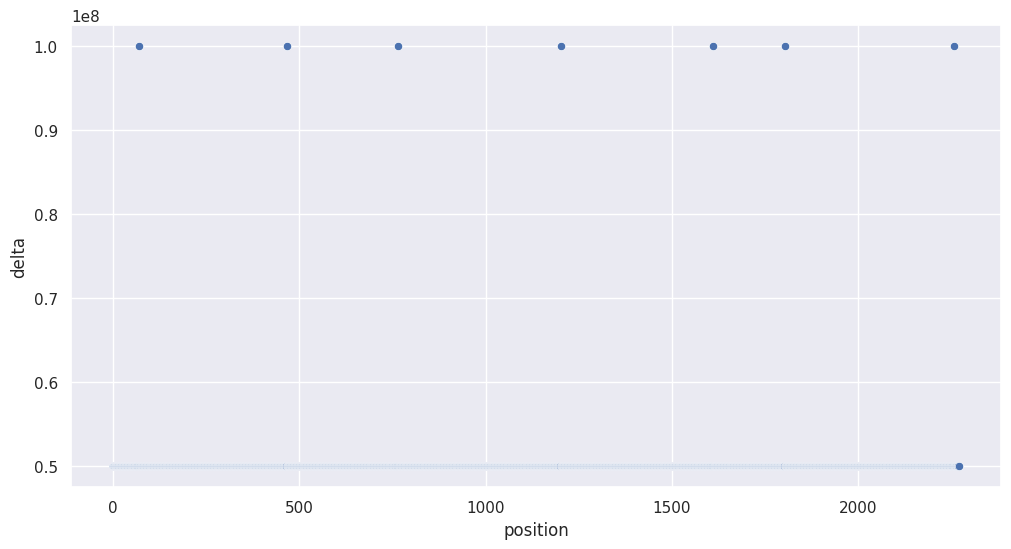

In [172]:
deltas = np.diff(df['#timestamp [ns]'])
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

In [173]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].apply(lambda x: f"{x:.0f}")

In [174]:
df.head(5)

,#timestamp [ns],filename
0,1413393212255760384,1413393212255760384.png
1,1413393212305760512,1413393212305760512.png
2,1413393212355760384,1413393212355760384.png
3,1413393212405760512,1413393212405760512.png
4,1413393212455760384,1413393212455760384.png


In [175]:
df.to_csv(f'{working_dir}/mav0_euroc/{camera_type}/data_modified_frame_drops.csv', index=False)

In [176]:
working_dir

'/home/shiva/Datasets/V2_01_easy/V2_01_easy/'

In [177]:
filename = 'data_modified_frame_drops.csv'

In [178]:
!cp {working_dir}/mav0_euroc/{camera_type}/{filename} {working_dir}/mav0/{camera_type}/{filename}